In [27]:
import pandas as pd
import importlib
import itertools
from datetime import datetime
import matplotlib.pyplot as plt

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMLEquiponderada, EstrategiaMLMinVarAlphaTilt
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

In [28]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers}")

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA', 'ALV.DE', 'ABI.BR', 'ARGX.BR', 'ASML.AS', 'CS.PA', 'BAS.DE', 'BAYN.DE', 'BBVA.MC', 'SAN.MC', 'BMW.DE', 'BNP.PA', 'BN.PA', 'DBK.DE', 'DB1.DE', 'DHL.DE', 'DTE.DE', 'ENEL.MI', 'ENI.MI', 'EL.PA', 'RACE.MI', 'RMS.PA', 'IBE.MC', 'ITX.MC', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'OR.PA', 'MC.PA', 'MBG.DE', 'MUV2.DE', 'NDA-FI.HE', 'PRX.AS', 'RHM.DE', 'SAF.PA', 'SGO.PA', 'SAN.PA', 'SAP.DE', 'SU.PA', 'SIE.DE', 'ENR.DE', 'TTE.PA', 'DG.PA', 'UCG.MI', 'VOW.DE', 'WKL.AS']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_107512\1949759624.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [105]:
start_date = "2025-06-01"
end_date = "2025-12-01"
universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="^STOXX50E")
nsim = 3  # Número de simulaciones
resultados = []

for i in range(nsim):
    modelo = RandomForestModel(
        n_estimators=250,
        max_depth=4,
        class_weight=None,
        random_state=428 + 100*i,
        positive_class_weight=10.0
    )
    estrategia = EstrategiaMLEquiponderada(
        modelo=modelo,
        n_activos_obj=15,
        umbral_salida=22
    )
    engine = BacktestEngine(
        universo=universo,
        proveedor=proveedor,
        feature_engineer=fe,
        estrategia=estrategia,
        start_date=start_date,
        end_date=end_date,
        len_ventana=4,
        nominal=10000000
    )
    fechas, serie_estrategia, metrics_view = engine.print_results(bmks=["^STOXX50E"], plot=False)
    resultados.append(serie_estrategia)

# Unir resultados por fecha
resultados_df = pd.concat(resultados, axis=1)
resultados_df.columns = [f"sim_{i+1}" for i in range(nsim)]

# Calcular media y banda de confianza
media = resultados_df.mean(axis=1)
std = resultados_df.std(axis=1)
upper = media + std
lower = media - std

# Benchmark
df_bmk = proveedor.download_prices_daily(["^STOXX50E"], start_date, end_date)
df_bmk["Fecha"] = pd.to_datetime(df_bmk["Fecha"])
serie_bmk = df_bmk.set_index("Fecha")["Precio_Close"].reindex(media.index).ffill()
serie_bmk = serie_bmk / serie_bmk.iloc[0]

[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


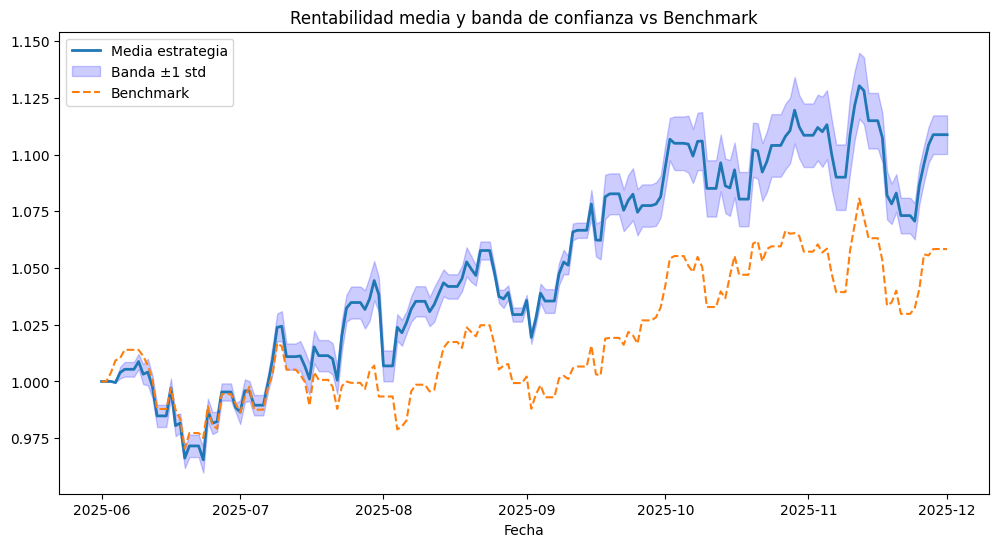

Métricas medias:


,Estrategia,Benchmark
Rentabilidad total,0.108804,0.058371
Rentabilidad anualizada,0.152836,0.081254
Volatilidad anualizada,0.121137,0.102984
Sharpe,1.234694,0.809896
Sortino,1.824372,1.195910
Max Drawdown,-0.052828,-0.047037
Calmar,2.893083,1.727431
Win rate,0.382514,0.371585
Mejor periodo,0.022614,0.017593
Peor periodo,-0.030285,-0.018832


In [106]:

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(media.index, media, label="Media estrategia", linewidth=2)
plt.fill_between(media.index, lower, upper, color="blue", alpha=0.2, label="Banda ±1 std")
plt.plot(media.index, serie_bmk, label="Benchmark", linestyle="--")
plt.title("Rentabilidad media y banda de confianza vs Benchmark")
plt.xlabel("Fecha")
plt.legend()
plt.show()

# Métricas medias
from auxiliary_functions import build_metrics_table
metrics = build_metrics_table({"Estrategia": media, "Benchmark": serie_bmk}, periods_per_year=252, rf_annual=0.0)
print("Métricas medias:")
display(metrics.T)

In [77]:
start_date = "2025-06-01"
end_date = "2025-12-01"
universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="^STOXX50E")
nsim = 50  # Número de simulaciones
resultados = []

for i in range(nsim):
    modelo = RandomForestModel(
        n_estimators=250,
        max_depth=4,
        class_weight=None,
        random_state=428 + 100*i,
        positive_class_weight=10.0
    )
    estrategia = EstrategiaMLEquiponderada(
        modelo=modelo,
        n_activos_obj=12,
        umbral_salida=15
    )
    engine = BacktestEngine(
        universo=universo,
        proveedor=proveedor,
        feature_engineer=fe,
        estrategia=estrategia,
        start_date=start_date,
        end_date=end_date,
        len_ventana=4,
        nominal=10000000
    )
    fechas, serie_estrategia, metrics_view = engine.print_results(bmks=["^STOXX50E"], plot=False)
    resultados.append(serie_estrategia)

# Unir resultados por fecha
resultados_df = pd.concat(resultados, axis=1)
resultados_df.columns = [f"sim_{i+1}" for i in range(nsim)]

# Calcular media y banda de confianza
media = resultados_df.mean(axis=1)
std = resultados_df.std(axis=1)
upper = media + std
lower = media - std

# Benchmark
df_bmk = proveedor.download_prices_daily(["^STOXX50E"], start_date, end_date)
df_bmk["Fecha"] = pd.to_datetime(df_bmk["Fecha"])
serie_bmk = df_bmk.set_index("Fecha")["Precio_Close"].reindex(media.index).ffill()
serie_bmk = serie_bmk / serie_bmk.iloc[0]

[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed

1 Failed download:
['BMW.DE']: TypeError("'NoneType' object is not subscriptable")
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


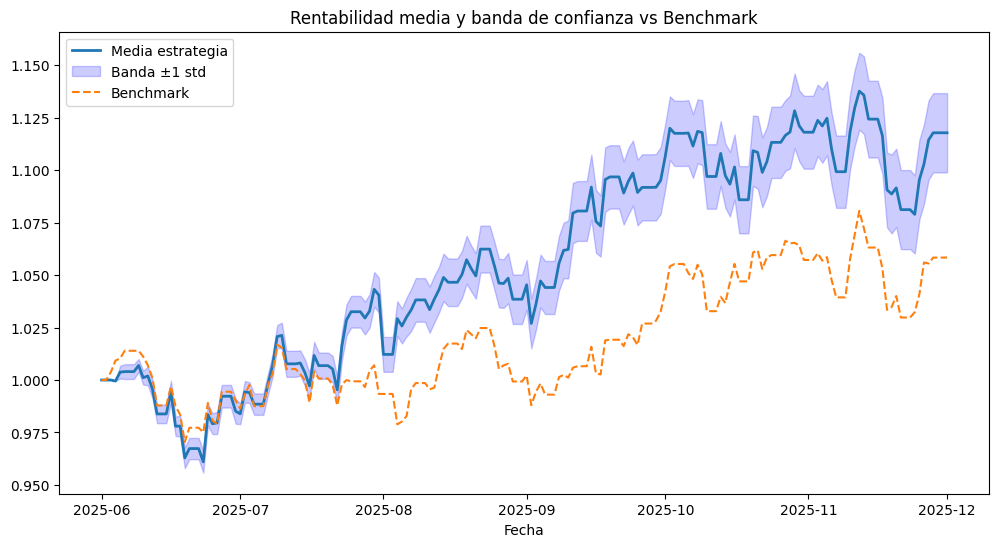

Métricas medias:


,Estrategia,Benchmark
Rentabilidad total,0.117862,0.058371
Rentabilidad anualizada,0.165824,0.081254
Volatilidad anualizada,0.122736,0.102984
Sharpe,1.311473,0.809896
Sortino,1.978842,1.195910
Max Drawdown,-0.051626,-0.047037
Calmar,3.212022,1.727431
Win rate,0.387978,0.371585
Mejor periodo,0.023426,0.017593
Peor periodo,-0.027194,-0.018832


In [78]:

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(media.index, media, label="Media estrategia", linewidth=2)
plt.fill_between(media.index, lower, upper, color="blue", alpha=0.2, label="Banda ±1 std")
plt.plot(media.index, serie_bmk, label="Benchmark", linestyle="--")
plt.title("Rentabilidad media y banda de confianza vs Benchmark")
plt.xlabel("Fecha")
plt.legend()
plt.show()

# Métricas medias
from auxiliary_functions import build_metrics_table
metrics = build_metrics_table({"Estrategia": media, "Benchmark": serie_bmk}, periods_per_year=252, rf_annual=0.0)
print("Métricas medias:")
display(metrics.T)

In [103]:
start_date = "2025-06-02"
end_date = "2025-12-01"
universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="^STOXX50E")
nsim = 3  # Número de simulaciones
resultados = []

for i in range(nsim):
    modelo = RandomForestModel(
        n_estimators=250,
        max_depth=4,
        class_weight=None,
        random_state=428 + 100*i,
        positive_class_weight=10.0
    )
    estrategia = EstrategiaMLMinVarAlphaTilt(
        modelo=modelo,
        n_activos_obj=20,
        umbral_salida=30,
        p_neutral=0.55,        # más conservador que 0.50
        alpha_scale=1.0,
        lambda_risk=10.0,       # subir para bajar volatilidad
        lambda_tc=0.001,       # subir para rotar menos
        w_max=0.15,
        turnover_max=0.20,
        no_trade_band=0.004,   # 40 bps de banda
        coste_transaccion=0.0005,  # 5 bps
        utility_buffer=0.0001,     # histéresis adicional
        min_hist_obs=50
    )
    engine = BacktestEngine(
        universo=universo,
        proveedor=proveedor,
        feature_engineer=fe,
        estrategia=estrategia,
        start_date=start_date,
        end_date=end_date,
        len_ventana=4,
        nominal=10000000
    )
    fechas, serie_estrategia, metrics_view = engine.print_results(bmks=["^STOXX50E"], plot=False)
    resultados.append(serie_estrategia)

# Unir resultados por fecha
resultados_df = pd.concat(resultados, axis=1)
resultados_df.columns = [f"sim_{i+1}" for i in range(nsim)]

# Calcular media y banda de confianza
media = resultados_df.mean(axis=1)
std = resultados_df.std(axis=1)
upper = media + std
lower = media - std

# Benchmark
df_bmk = proveedor.download_prices_daily(["^STOXX50E"], start_date, end_date)
df_bmk["Fecha"] = pd.to_datetime(df_bmk["Fecha"])
serie_bmk = df_bmk.set_index("Fecha")["Precio_Close"].reindex(media.index).ffill()
serie_bmk = serie_bmk / serie_bmk.iloc[0]

[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  53 of 53 completed
[*********************100%***********************]  53 of 53 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-06-04


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


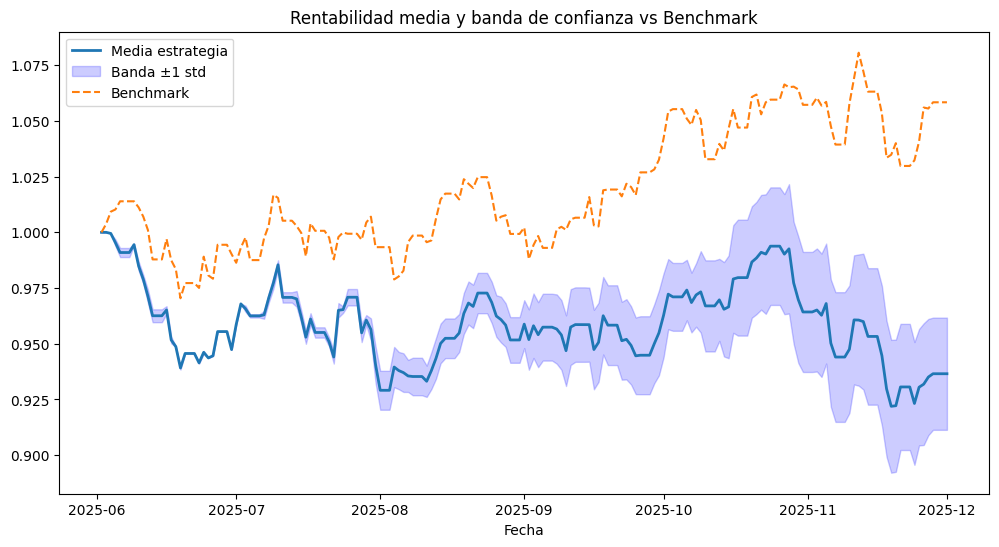

Métricas medias:


,Estrategia,Benchmark
Rentabilidad total,-0.063473,0.058371
Rentabilidad anualizada,-0.086799,0.081718
Volatilidad anualizada,0.096887,0.103267
Sharpe,-0.888783,0.812112
Sortino,-1.190716,1.199191
Max Drawdown,-0.078089,-0.047037
Calmar,-1.111539,1.737300
Win rate,0.335165,0.373626
Mejor periodo,0.022234,0.017593
Peor periodo,-0.018357,-0.018832


In [104]:

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(media.index, media, label="Media estrategia", linewidth=2)
plt.fill_between(media.index, lower, upper, color="blue", alpha=0.2, label="Banda ±1 std")
plt.plot(media.index, serie_bmk, label="Benchmark", linestyle="--")
plt.title("Rentabilidad media y banda de confianza vs Benchmark")
plt.xlabel("Fecha")
plt.legend()
plt.show()

# Métricas medias
from auxiliary_functions import build_metrics_table
metrics = build_metrics_table({"Estrategia": media, "Benchmark": serie_bmk}, periods_per_year=252, rf_annual=0.0)
print("Métricas medias:")
display(metrics.T)